In [1]:
import torch
import torch.nn as nn
from torchvision import datasets,transforms
import torch.optim as optim
from torch.utils.data import DataLoader

In [2]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [4]:
train_dataset=datasets.MNIST('./data',download=True,train=True,transform=transform)
test_dataset=datasets.MNIST('./data',download=True,train=False,transform=transform)

train_dataloader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_dataloader=DataLoader(test_dataset,shuffle=False,batch_size=1000)

In [6]:
%pip install matplotlib

     ---------------------------------------- 8.1/8.1 MB 2.9 MB/s eta 0:00:00
     -------------------------------------- 225.2/225.2 kB 2.8 MB/s eta 0:00:00
     ---------------------------------------- 2.3/2.3 MB 1.2 MB/s eta 0:00:00
     ---------------------------------------- 73.8/73.8 kB 1.4 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 7.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import matplotlib.pyplot as plt
images,labels=next(iter(train_dataloader))

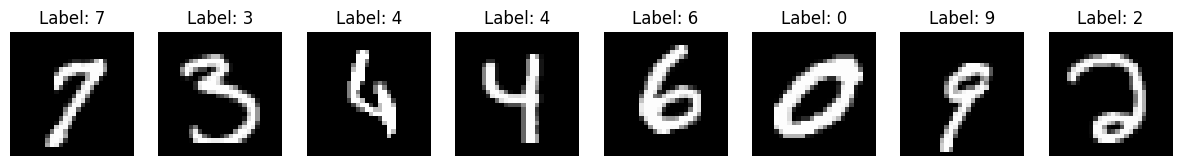

In [8]:
fig,axes=plt.subplots(1,8,figsize=(15,2))

for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(),cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.show()

In [16]:
#Teacher Model

class TeacherModel(nn.Module):

    def __init__(self,hidden1=512,hidden2=512):
        super().__init__()
        self.net=nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,hidden1),
            nn.ReLU(),
            nn.Linear(hidden1,hidden2),
            nn.ReLU(),
            nn.Linear(hidden2,10)
        )
    
    def forward(self,x):
        return self.net(x)

In [42]:
teacher=TeacherModel(hidden1=512,hidden2=256)

In [43]:
print(teacher)

TeacherModel(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [44]:
#train teacher model

def train_teacher(model,loader,epochs=3,lr=1e-3):

    optimizer=optim.Adam(model.parameters(),lr=lr)

    loss_fn=nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        total_loss=0
        for images,labels in loader:
            output=model(images)
            loss=loss_fn(output,labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        print(f"Teacher Model {epoch+1}: Loss ={total_loss/len(loader):.4f}")

In [45]:
train_teacher(model=teacher,loader=train_dataloader)

Teacher Model 1: Loss =0.3048
Teacher Model 2: Loss =0.1363
Teacher Model 3: Loss =0.1046


In [46]:
print(teacher.state_dict()) #updated weights

OrderedDict([('net.1.weight', tensor([[-0.0202,  0.0163,  0.0156,  ...,  0.0199,  0.0138, -0.0090],
        [-0.0223, -0.0251,  0.0403,  ...,  0.0314,  0.0318, -0.0217],
        [ 0.0243,  0.0098, -0.0143,  ...,  0.0309,  0.0019, -0.0269],
        ...,
        [-0.0167, -0.0069,  0.0072,  ..., -0.0164,  0.0085,  0.0110],
        [ 0.0249,  0.0396,  0.0295,  ...,  0.0445,  0.0301,  0.0015],
        [-0.0036, -0.0108, -0.0269,  ...,  0.0066, -0.0215,  0.0289]])), ('net.1.bias', tensor([-0.0176,  0.0208,  0.0202,  0.0245, -0.0138, -0.0201, -0.0011, -0.0336,
        -0.0322,  0.0100,  0.0070, -0.0178, -0.0231, -0.0134, -0.0233, -0.0101,
        -0.0074,  0.0197, -0.0396,  0.0069,  0.0043,  0.0260,  0.0029, -0.0158,
         0.0204, -0.0067,  0.0098, -0.0173,  0.0017,  0.0113,  0.0055,  0.0032,
        -0.0282, -0.0121, -0.0365, -0.0374,  0.0148, -0.0333, -0.0123,  0.0203,
         0.0137, -0.0045,  0.0086, -0.0135, -0.0157, -0.0396,  0.0086,  0.0201,
         0.0036, -0.0167, -0.0033,  0.0

In [47]:
#student model

class StudentModel(nn.Module):
    def __init__(self,hidden1=128):
        super().__init__()
        self.net=nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,hidden1),
            nn.ReLU(),
            nn.Linear(hidden1,10)
        )
    
    def forward(self,x):
        return self.net(x)

In [48]:
student=StudentModel(hidden1=128)

In [49]:
print(student)

StudentModel(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [50]:
#train teacher model

def pretrain_student(model,loader,epochs=1,lr=1e-3):

    optimizer=optim.Adam(model.parameters(),lr=lr)

    loss_fn=nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        # total_loss=0
        for images,labels in loader:
            output=model(images)
            loss=loss_fn(output,labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        #     total_loss+=loss.item()
        # print(f"Teacher Model {epoch+1}: Loss ={total_loss/len(loader):.4f}")

In [51]:
pretrain_student(student,train_dataloader)

In [52]:
#Distillation training

temperature=2.0
alpha=0.7
ce_loss=nn.CrossEntropyLoss()
kl_loss=nn.KLDivLoss(reduction="batchmean")
optimizer=optim.Adam(student.parameters(),lr=1e-3)

In [53]:
def distill(teacher,student,loader,epochs=3):
    
    for epoch in range(epochs):
        student.train()

        total_loss=0

        for images,labels in loader:

            with torch.no_grad():
                t_logits=teacher(images)
                t_probs=torch.softmax(t_logits/temperature,dim=1)

            
            s_logits=student(images)
            s_log_probs=torch.log_softmax(s_logits / temperature,dim=1)

            loss_soft=kl_loss(s_log_probs,t_probs)*(temperature**2)

            loss_hard=ce_loss(s_logits,labels)

            loss=alpha*loss_soft+(1-alpha)*loss_hard

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss+=loss.item()

        print(f"Student Epoch: {epoch+1}: Loss : {total_loss/len(loader):.4f}")


    

In [54]:
distill(teacher,student,train_dataloader)

Student Epoch: 1: Loss : 0.2906
Student Epoch: 2: Loss : 0.1416
Student Epoch: 3: Loss : 0.1056


In [55]:
#evaluate
def evaluate(model,loader,name="Model"):
    model.eval()

    total,correct=0,0

    with torch.no_grad():
        for images,labels in loader:
            output=model(images)
            preds=output.argmax(dim=1)
            correct+=(preds==labels).sum().item()
            total+=labels.size(0)
    acc=correct/total*100
    print(f"{name} Accuracy: {acc:.2f}%")
    return acc

In [56]:
evaluate(teacher,test_dataloader,"Teacher")

Teacher Accuracy: 96.48%


96.48

In [57]:
evaluate(student,test_dataloader,"Student")

Student Accuracy: 96.57%


96.57

In [59]:
#prediction
def predict(model,x):
    model.eval()
    with torch.no_grad():
        out=model(x)
        return out.argmax(dim=1)

In [60]:
sample_batch,sample_labels=next(iter(test_dataloader))

In [61]:
result=predict(student,sample_batch)

print("Sample Prediction by Students: ",result[:20])

print("True Labels: ",sample_labels[:20])

Sample Prediction by Students:  tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4])
True Labels:  tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4])


In [62]:
torch.save(student.state_dict(),"distilled_student.pth")
print("Student model saved as distilled_student.pth")

Student model saved as distilled_student.pth


In [63]:
import warnings
warnings.filterwarnings("ignore",category=FutureWarning)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import datasets,transforms

from datasets import load_dataset

from transformers import AutoTokenizer,DataCollatorWithPadding

In [30]:
batch_size =16
lr=5e-5
epochs=1
alpha_soft=0.5
max_len=128
temperature=2
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#load dataset

raw=load_dataset("tweet_eval","sentiment")

In [4]:
label_feature =raw["train"].features["label"]

In [5]:
print("Label names: ",label_feature.names)

Label names:  ['negative', 'neutral', 'positive']


In [6]:
train_data=raw["train"].shuffle(seed=42).select(range(2500))

val_data=raw["validation"]

In [7]:
tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")

In [8]:
def tokenize(example):
    return tokenizer(example["text"],truncation=True,max_length=max_len)

In [9]:
tokenized={}

In [10]:
tokenized['train']=train_data.map(tokenize,batched=True,remove_columns=["text"])
tokenized['validation']=val_data.map(tokenize,batched=True,remove_columns=['text'])

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [11]:
tokenized

{'train': Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 2500
 }),
 'validation': Dataset({
     features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 2000
 })}

In [12]:
#data collator

collator=DataCollatorWithPadding(tokenizer,pad_to_multiple_of=8)

train_dl=DataLoader(tokenized['train'],shuffle=True,batch_size=batch_size,collate_fn=collator)

val_dl=DataLoader(tokenized['validation'],shuffle=False,batch_size=batch_size,collate_fn=collator)

In [13]:
from transformers import AutoModelForSequenceClassification,AutoTokenizer

In [14]:
num_labels=3

In [38]:
teacher=AutoModelForSequenceClassification.from_pretrained("bert-large-uncased",num_labels=num_labels).to(device)

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

c:\Users\INMOR14\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\INMOR14\.cache\huggingface\hub\models--bert-large-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-large-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [39]:
student=AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=num_labels).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
for p in teacher.parameters():
    p.requires_grad=False

In [41]:
teacher.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,

In [42]:
ce=nn.CrossEntropyLoss()

In [43]:
kl_loss=nn.KLDivLoss(reduction="batchmean")

In [44]:
optimizer=optim.AdamW(student.parameters(),lr=lr)

In [45]:
from transformers import get_scheduler

In [46]:
lr_scheduler=get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=len(train_dl)*epochs
)

In [47]:
from tqdm.auto import tqdm

In [48]:
def distill():
    student.train()
    pbar=tqdm(train_dl,desc="Train")

    for batch in pbar:
        input_ids=batch["input_ids"].to(device)
        attention=batch["attention_mask"].to(device)
        labels=batch["labels"].to(device)


        with torch.no_grad():
            t_logits=teacher(input_ids,attention_mask=attention).logits
            t_soft=torch.softmax(t_logits/temperature,dim=1)

        s_logits=student(input_ids,attention_mask=attention).logits
        s_soft=torch.log_softmax(s_logits/temperature,dim=1)

        loss_soft=kl_loss(s_soft,t_soft)*(temperature**2)
        loss_hard=ce(s_logits,labels)
        loss=alpha_soft*loss_soft+(1-alpha_soft)*loss_hard

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        pbar.set_postfix({"Loss":f"{loss.item():.4f}"})

In [49]:
def evaluate():
    student.eval()
    correct=total=0

    with torch.no_grad():
        for batch in val_dl:
            input_ids=batch["input_ids"].to(device)
            attention=batch["attention_mask"].to(device)
            labels=batch["labels"].to(device)

            out=student(input_ids,attention_mask=attention).logits
            preds=out.argmax(dim=1)
            correct+=(preds==labels).sum().item()
            total+=labels.size(0)
    return round(correct/total*100,2)


In [50]:
for epoch in range(1,epochs+1):
    distill()
    acc=evaluate()
    print(f"Epoch {epoch}/{epochs} | Validation Accuracy: {acc} ")

Train:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1/1 | Validation Accuracy: 61.05 


In [51]:
student.save_pretrained("distilled_student_model")
tokenizer.save_pretrained("distilled_student_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilled_student_model\\tokenizer_config.json',
 'distilled_student_model\\tokenizer.json')

In [52]:
#load test set

test_set=load_dataset("tweet_eval","sentiment",split="test[:500]")
tokenized_test=test_set.map(tokenize,batched=True,remove_columns=["text"])
tokenized_test.set_format(type="torch",columns=["input_ids","attention_mask","label"])
test_dl=DataLoader(tokenized_test,batch_size=batch_size,shuffle=False,collate_fn=collator)

In [53]:
from sklearn.metrics import accuracy_score
import time

def predict_and_evaluate(model,name,test_dl):
    model.eval()
    all_preds,all_labels=[],[]
    start_time=time.time()

    with torch.no_grad():
        for batch in test_dl:
            ids=batch["input_ids"].to(device)
            attn=batch["attention_mask"].to(device)
            labels=batch["labels"].to(device)

            logits=model(ids,attention_mask=attn).logits
            preds=torch.argmax(logits,dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    
    total_time=time.time()-start_time
    acc_score=accuracy_score(all_preds,all_labels)
    avg_time=total_time/len(test_dl.dataset)

    print(f"\n Name: {name} \n")
    print(f"Accuracy score: {acc_score:.2f}\n")
    print(f"Total inference time: {total_time}")
    print(f"Avg Time per sample: {avg_time}")
    return acc,total_time,avg_time



In [54]:
predict_and_evaluate(teacher,"Teacher",test_dl=test_dl)
predict_and_evaluate(student,"Student",test_dl=test_dl)


 Name: Teacher 

Accuracy score: 0.48

Total inference time: 32.728785276412964
Avg Time per sample: 0.06545757055282593

 Name: Student 

Accuracy score: 0.57

Total inference time: 8.960870504379272
Avg Time per sample: 0.017921741008758544


(61.05, 8.960870504379272, 0.017921741008758544)